In [104]:
from pathlib import Path

import pandas as pd

csv_path = "2Probe.csv"
data = pd.read_csv(csv_path)
data.head()


,row_type,measurement_index,target_x_mm,target_y_mm,target_force_N,actual_x_mm,actual_y_mm,position_time_s,actual_force_N,force_time_s,...,eit_55,eit_56,eit_57,eit_58,eit_59,eit_60,eit_61,eit_62,eit_63,eit_time_s
0,baseline,NaN,NaN,NaN,NaN,NaN,NaN,0.107663,NaN,NaN,...,0.1752,0.1537,0.1551,0.1547,0.1462,0.1514,0.2250,0.1490,0.1771,0.107663
1,baseline,1.0,104.435897,14.794872,4.0,104.44,14.79,124.801230,0.0000,NaN,...,0.1766,0.1543,0.1560,0.1558,0.1471,0.1545,0.2193,0.1507,0.1786,124.811329
2,contact,1.0,104.435897,14.794872,4.0,104.44,14.79,124.801230,4.4018,146.863373,...,0.1644,0.1540,0.1556,0.1554,0.1463,0.1543,0.2189,0.1587,0.1648,147.915774
3,baseline,2.0,102.794872,17.968661,2.0,102.79,17.97,149.756625,0.0000,NaN,...,0.1872,0.1557,0.1578,0.1573,0.1485,0.1569,0.2233,0.1590,0.1900,149.779838
4,contact,2.0,102.794872,17.968661,2.0,102.79,17.97,149.756625,2.0840,160.401602,...,0.1317,0.1551,0.1529,0.1564,0.1490,0.1618,0.2275,0.1555,0.1344,161.430477


In [105]:
import re

eit_cols = [c for c in data.columns if re.fullmatch(r"eit_\d+", c)]
eit_labels = [c.removeprefix("eit_") for c in eit_cols]
eit_col_by_index = {int(label): col for label, col in zip(eit_labels, eit_cols)}

print(f"Loaded {len(data)} samples with {len(eit_cols)} EIT channels")


Loaded 9601 samples with 64 EIT channels


In [106]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGURE_DIR = Path("../../Figures")
EXPORT_FIGURES = True

PAPER_STYLE = {
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.labelsize": 9,
    "axes.titlesize": 9.5,
    "axes.titleweight": "bold",
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "legend.title_fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "grid.linewidth": 0.45,
    "lines.linewidth": 1.25,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "savefig.facecolor": "white",
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}
plt.rcParams.update(PAPER_STYLE)

PHASE_PALETTE = {
    "baseline": "#667085",
    "descend": "#2563eb",
    "dwell": "#d97706",
    "retract": "#059669",
    "rest": "#be123c",
    "unknown": "#7c3aed",
}
MAIN_LINE = "#1f2937"
SECONDARY_LINE = "#64748b"
ACCENT = "#0f766e"


def phase_color(phase):
    return PHASE_PALETTE.get(str(phase).lower(), PHASE_PALETTE["unknown"])


def polish_axis(ax, xlabel=None, ylabel=None, title=None, grid=True):
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title, pad=7)
    if grid:
        ax.grid(True, axis="y", color="#d0d5dd", alpha=0.75)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#475467")
    ax.spines["bottom"].set_color("#475467")
    ax.tick_params(colors="#344054", labelcolor="#344054")
    return ax


def tidy_legend(ax, title=None, loc="best", ncol=1):
    handles, labels = ax.get_legend_handles_labels()
    unique = {}
    for handle, label in zip(handles, labels):
        if label and not label.startswith("_") and label not in unique:
            unique[label] = handle
    if unique:
        return ax.legend(
            unique.values(),
            unique.keys(),
            title=title,
            loc=loc,
            ncol=ncol,
            frameon=False,
            handlelength=1.5,
            handletextpad=0.45,
            borderaxespad=0.35,
        )
    return None


def save_paper_figure(fig, stem, *, formats=("svg", "pdf")):
    if not EXPORT_FIGURES:
        return []
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    paths = []
    for fmt in formats:
        out = FIGURE_DIR / f"{stem}.{fmt}"
        fig.savefig(out, format=fmt)
        paths.append(out)
    return paths


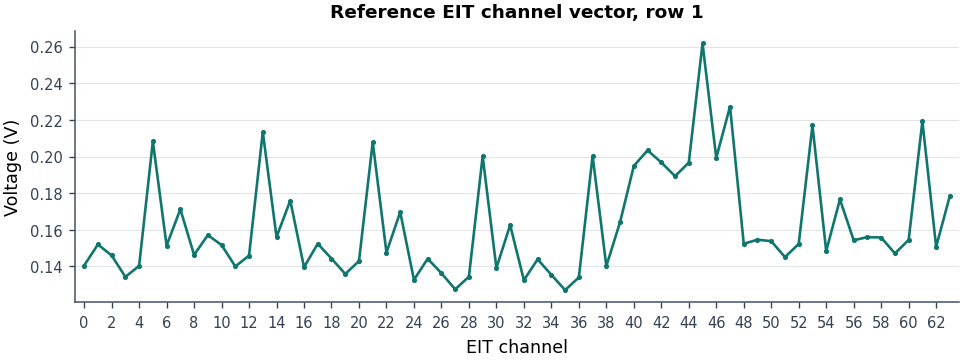

In [107]:
reference_row = 1

reference_values = data.loc[reference_row, eit_cols].to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(6.9, 2.6), constrained_layout=True)

ax.plot(
    range(len(reference_values)),
    reference_values,
    color=ACCENT,
    linewidth=1.35,
)
ax.scatter(
    range(len(reference_values)),
    reference_values,
    color=ACCENT,
    s=7,
    linewidths=0,
    zorder=3,
)

label_step = max(1, int(len(eit_labels) / 24))
ax.set_xticks(range(0, len(eit_cols), label_step))
ax.set_xticklabels(eit_labels[::label_step], rotation=0)
polish_axis(
    ax,
    xlabel="EIT channel",
    ylabel="Voltage (V)",
    title=f"Reference EIT channel vector, row {reference_row}",
)
ax.margins(x=0.01)

save_paper_figure(fig, f"RefSig{Path(csv_path).stem}")
plt.show()


In [108]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


csv_path = Path("MultiForceProbe.csv")
raw_data = pd.read_csv(csv_path)

row_type = raw_data["row_type"].astype(str).str.lower() if "row_type" in raw_data.columns else pd.Series("eit", index=raw_data.index)

eit_cols = sorted(
    [col for col in raw_data.columns if col.startswith("eit_") and col.removeprefix("eit_").isdigit()],
    key=lambda col: int(col.removeprefix("eit_")),
)
if not eit_cols:
    raise ValueError("No EIT channel columns were found. Expected columns named eit_<index>.")
eit_col_by_index = {int(col.removeprefix("eit_")): col for col in eit_cols}

# Coerce numeric columns so blank force-row EIT cells become NaN instead of object dtype.
raw_data[eit_cols] = raw_data[eit_cols].apply(pd.to_numeric, errors="coerce")

force_col = "force_N" if "force_N" in raw_data.columns else None
if force_col is None:
    for candidate in ["actual_force_N", "force_sample_N", "latest_force_N"]:
        if candidate in raw_data.columns:
            force_col = candidate
            break
if force_col is None:
    raise KeyError("Expected a force column such as force_N or actual_force_N.")
raw_data[force_col] = pd.to_numeric(raw_data[force_col], errors="coerce")

timestamp_col = "sensor_time_s" if "sensor_time_s" in raw_data.columns else "eit_time_s"
if timestamp_col not in raw_data.columns:
    raise KeyError(f"Expected a time column such as sensor_time_s or eit_time_s in {csv_path}.")
raw_data[timestamp_col] = pd.to_numeric(raw_data[timestamp_col], errors="coerce")

metadata_cols = [
    col
    for col in ["row_type", "sample_index", "bunch_index", "phase", "target_z_mm", "actual_z_mm", "phase_elapsed_s"]
    if col in raw_data.columns
]
if "bunch_index" in raw_data.columns:
    raw_data["bunch_index"] = pd.to_numeric(raw_data["bunch_index"], errors="coerce")

force_data = (
    raw_data.loc[row_type.eq("force"), [*metadata_cols, timestamp_col, force_col]]
    .rename(columns={timestamp_col: "timestamp_s", force_col: "force_N"})
    .dropna(subset=["timestamp_s", "force_N"])
    .sort_values("timestamp_s")
    .reset_index(drop=True)
)

eit_mask = row_type.isin(["eit", "baseline_eit"])
eit_data = (
    raw_data.loc[eit_mask, [*metadata_cols, timestamp_col, "eit_clipping", *eit_cols] if "eit_clipping" in raw_data.columns else [*metadata_cols, timestamp_col, *eit_cols]]
    .rename(columns={timestamp_col: "timestamp_s"})
    .dropna(subset=["timestamp_s"])
    .sort_values("timestamp_s")
    .reset_index(drop=True)
)

if "bunch_index" in raw_data.columns:
    bunch_start_times = raw_data.dropna(subset=["bunch_index", timestamp_col]).groupby("bunch_index")[timestamp_col].min()
    force_data["bunch_elapsed_s"] = force_data["timestamp_s"] - force_data["bunch_index"].map(bunch_start_times)
    eit_data["bunch_elapsed_s"] = eit_data["timestamp_s"] - eit_data["bunch_index"].map(bunch_start_times)
else:
    bunch_start_times = pd.Series(dtype=float)

eit_values = eit_data[eit_cols]
if "row_type" in eit_data.columns:
    baseline_rows = eit_data[eit_data["row_type"].astype(str).str.lower().eq("baseline_eit")]
else:
    baseline_rows = eit_data.iloc[:1]
if baseline_rows.empty:
    baseline_vector = eit_values.iloc[0]
else:
    baseline_vector = baseline_rows[eit_cols].iloc[0]

eit_delta = eit_values.subtract(baseline_vector, axis="columns")
eit_data["eit_mean"] = eit_values.mean(axis=1)
eit_data["eit_delta_mean"] = eit_delta.mean(axis=1)
eit_data["eit_delta_rms"] = np.sqrt((eit_delta ** 2).mean(axis=1))
eit_data["eit_delta_peak_abs"] = eit_delta.abs().max(axis=1)

# Per-press onset sync: estimate when force and EIT first depart from their
# local pre-contact baseline, then shift force timestamps onto EIT timing.
apply_per_press_onset_sync = True
sync_force_threshold_N = 0.05
sync_baseline_phase = "descend"
sync_force_onset_phases = {"dwell"}
sync_eit_onset_phases = {"descend", "dwell"}
sync_baseline_noise_sigma = 6.0
sync_min_eit_abs_change_V = 2e-4
sync_min_eit_derivative_V_per_s = 1e-3
sync_min_baseline_rows = 3
sync_baseline_sample_count = 5
sync_min_force_peak_delta_N = 0.10
sync_max_abs_offset_s = 0.75
sync_retract_drop_threshold_N = 0.015
sync_retract_derivative_threshold_N_per_s = -0.10


def _local_baseline_rows(frame, phase_name):
    baseline_count = min(max(sync_min_baseline_rows, sync_baseline_sample_count), len(frame))
    if "phase" in frame.columns:
        phase_rows = frame.loc[frame["phase"].astype(str).str.lower().eq(phase_name)]
        if len(phase_rows) >= sync_min_baseline_rows:
            return phase_rows.head(min(sync_baseline_sample_count, len(phase_rows)))
    return frame.head(baseline_count)


def _phase_search_rows(frame, phase_names):
    if "phase" not in frame.columns:
        return frame
    rows = frame.loc[frame["phase"].astype(str).str.lower().isin(phase_names)]
    return rows if not rows.empty else frame


def _add_derivative(frame, value_col, derivative_col):
    frame = frame.sort_values("elapsed_s").copy()
    dt = frame["elapsed_s"].diff()
    dv = frame[value_col].diff()
    frame[derivative_col] = dv.divide(dt.where(dt.gt(0)))
    return frame


def estimate_press_sync_offsets(force_frame, eit_frame):
    if "bunch_index" not in force_frame.columns or "bunch_index" not in eit_frame.columns:
        return pd.DataFrame(columns=["bunch_index", "force_onset_s", "eit_onset_s", "sync_offset_s"])

    rows = []
    common_bunches = sorted(
        set(force_frame["bunch_index"].dropna().astype(int))
        & set(eit_frame["bunch_index"].dropna().astype(int))
    )
    for bunch_index in common_bunches:
        if bunch_index < 0:
            continue
        force_batch = (
            force_frame.loc[force_frame["bunch_index"].eq(bunch_index), ["timestamp_s", "force_N", *(["phase"] if "phase" in force_frame.columns else [])]]
            .dropna(subset=["timestamp_s", "force_N"])
            .sort_values("timestamp_s")
            .copy()
        )
        eit_batch = (
            eit_frame.loc[eit_frame["bunch_index"].eq(bunch_index), ["timestamp_s", "eit_mean", *(["phase"] if "phase" in eit_frame.columns else [])]]
            .dropna(subset=["timestamp_s", "eit_mean"])
            .sort_values("timestamp_s")
            .copy()
        )
        if len(force_batch) < sync_min_baseline_rows or len(eit_batch) < sync_min_baseline_rows:
            continue

        batch_start_s = min(force_batch["timestamp_s"].min(), eit_batch["timestamp_s"].min())
        force_batch["elapsed_s"] = force_batch["timestamp_s"] - batch_start_s
        eit_batch["elapsed_s"] = eit_batch["timestamp_s"] - batch_start_s

        force_baseline_rows = _local_baseline_rows(force_batch, sync_baseline_phase)
        eit_baseline_rows = _local_baseline_rows(eit_batch, sync_baseline_phase)
        force_baseline = force_baseline_rows["force_N"].median()
        eit_baseline = eit_baseline_rows["eit_mean"].median()

        force_batch["force_delta_N"] = force_batch["force_N"] - force_baseline
        eit_batch["eit_delta_V"] = eit_batch["eit_mean"] - eit_baseline

        force_search = _phase_search_rows(force_batch, sync_force_onset_phases)
        eit_search = _phase_search_rows(eit_batch, sync_eit_onset_phases)

        force_onset_rows = force_search.loc[force_search["force_delta_N"].gt(sync_force_threshold_N)]
        if force_onset_rows.empty:
            continue

        eit_noise = eit_baseline_rows["eit_mean"] - eit_baseline
        eit_mad = np.median(np.abs(eit_noise - np.median(eit_noise))) if len(eit_noise) else 0.0
        eit_sigma = 1.4826 * eit_mad
        eit_level_threshold = max(sync_min_eit_abs_change_V, sync_baseline_noise_sigma * eit_sigma)

        eit_search = _add_derivative(eit_search, "eit_delta_V", "eit_derivative_V_per_s")
        eit_baseline_for_derivative = _add_derivative(eit_baseline_rows.assign(
            elapsed_s=eit_baseline_rows["timestamp_s"] - batch_start_s,
            eit_delta_V=eit_baseline_rows["eit_mean"] - eit_baseline,
        ), "eit_delta_V", "eit_derivative_V_per_s")
        eit_derivative_noise = eit_baseline_for_derivative["eit_derivative_V_per_s"].dropna().abs()
        eit_derivative_threshold = max(
            sync_min_eit_derivative_V_per_s,
            sync_baseline_noise_sigma * eit_derivative_noise.median() if len(eit_derivative_noise) else 0.0,
        )
        eit_onset_rows = eit_search.loc[
            eit_search["eit_derivative_V_per_s"].abs().gt(eit_derivative_threshold)
            | eit_search["eit_delta_V"].abs().gt(eit_level_threshold)
        ]
        if eit_onset_rows.empty:
            continue

        force_onset_s = force_onset_rows.iloc[0]["elapsed_s"]
        eit_onset_s = eit_onset_rows.iloc[0]["elapsed_s"]
        rows.append({
            "bunch_index": bunch_index,
            "force_onset_s": force_onset_s,
            "eit_onset_s": eit_onset_s,
            "sync_offset_s": force_onset_s - eit_onset_s,
            "force_peak_delta_N": force_batch["force_delta_N"].max(),
            "eit_peak_abs_delta_V": eit_batch["eit_delta_V"].abs().max(),
            "eit_level_threshold_V": eit_level_threshold,
            "eit_derivative_threshold_V_per_s": eit_derivative_threshold,
            "eit_onset_derivative_V_per_s": eit_onset_rows.iloc[0]["eit_derivative_V_per_s"],
        })

    return pd.DataFrame(rows)


sync_offsets = estimate_press_sync_offsets(force_data, eit_data)
if sync_offsets.empty:
    sync_offsets_applied = sync_offsets.copy()
else:
    sync_offsets_applied = sync_offsets.loc[
        sync_offsets["force_peak_delta_N"].ge(sync_min_force_peak_delta_N)
        & sync_offsets["sync_offset_s"].abs().le(sync_max_abs_offset_s)
    ].copy()

if apply_per_press_onset_sync and not sync_offsets_applied.empty:
    sync_offset_by_bunch = sync_offsets_applied.set_index("bunch_index")["sync_offset_s"]

    # Treat force/robot timing as the reference clock. Positive sync_offset_s
    # means EIT moved before force, so shift EIT later by that offset.
    eit_data["timestamp_s_raw"] = eit_data["timestamp_s"]
    if "bunch_elapsed_s" in eit_data.columns:
        eit_data["bunch_elapsed_s_raw"] = eit_data["bunch_elapsed_s"]
    eit_data["sync_offset_s"] = eit_data["bunch_index"].map(sync_offset_by_bunch).fillna(0.0)
    eit_data["timestamp_s"] = eit_data["timestamp_s_raw"] + eit_data["sync_offset_s"]
    if "bunch_elapsed_s" in eit_data.columns:
        eit_data["bunch_elapsed_s"] = eit_data["bunch_elapsed_s_raw"] + eit_data["sync_offset_s"]

    # Keep raw force timing explicitly available for symmetry, but do not move it.
    force_data["timestamp_s_raw"] = force_data["timestamp_s"]
    if "bunch_elapsed_s" in force_data.columns:
        force_data["bunch_elapsed_s_raw"] = force_data["bunch_elapsed_s"]
    force_data["sync_offset_s"] = force_data["bunch_index"].map(sync_offset_by_bunch).fillna(0.0)

# Keep the robot/logger phase labels available for auditing.
for frame in [force_data, eit_data]:
    if "phase" in frame.columns and "phase_raw" not in frame.columns:
        frame["phase_raw"] = frame["phase"]


def align_force_retract_phase_to_force_change(force_frame):
    if "phase" not in force_frame.columns or "bunch_elapsed_s" not in force_frame.columns:
        return force_frame

    aligned = force_frame.copy()
    if "phase_raw" not in aligned.columns:
        aligned["phase_raw"] = aligned["phase"]
    aligned["force_retract_onset_s"] = np.nan
    aligned["phase_alignment"] = "force_raw"

    for bunch_index, batch in aligned.dropna(subset=["bunch_index", "bunch_elapsed_s", "force_N"]).groupby("bunch_index"):
        if bunch_index < 0:
            continue
        batch = batch.sort_values("bunch_elapsed_s").copy()
        raw_phase = batch["phase_raw"].astype(str).str.lower()
        dwell_rows = batch.loc[raw_phase.eq("dwell")]
        retract_rows = batch.loc[raw_phase.eq("retract")]
        if dwell_rows.empty or retract_rows.empty:
            continue

        plateau_force = dwell_rows.tail(min(5, len(dwell_rows)))["force_N"].median()
        raw_retract_start_s = retract_rows["bunch_elapsed_s"].min()
        rest_rows = batch.loc[raw_phase.eq("rest")]
        raw_rest_start_s = rest_rows["bunch_elapsed_s"].min() if not rest_rows.empty else np.inf

        search = batch.loc[
            batch["bunch_elapsed_s"].ge(raw_retract_start_s)
            & batch["bunch_elapsed_s"].lt(raw_rest_start_s)
        ].copy()
        if search.empty:
            continue
        search["force_drop_N"] = plateau_force - search["force_N"]
        dt = search["bunch_elapsed_s"].diff()
        search["force_derivative_N_per_s"] = search["force_N"].diff().divide(dt.where(dt.gt(0)))
        onset_rows = search.loc[
            search["force_drop_N"].ge(sync_retract_drop_threshold_N)
            | search["force_derivative_N_per_s"].le(sync_retract_derivative_threshold_N_per_s)
        ]
        retract_onset_s = onset_rows.iloc[0]["bunch_elapsed_s"] if not onset_rows.empty else raw_retract_start_s

        mask = aligned["bunch_index"].eq(bunch_index)
        aligned.loc[mask, "force_retract_onset_s"] = retract_onset_s
        times = aligned.loc[mask, "bunch_elapsed_s"]
        raw_phase_all = aligned.loc[mask, "phase_raw"].astype(str).str.lower()
        aligned.loc[mask, "phase"] = np.select(
            [raw_phase_all.eq("rest"), times.ge(retract_onset_s), raw_phase_all.isin(["dwell", "retract"])],
            ["rest", "retract", "dwell"],
            default="descend",
        )
        aligned.loc[mask, "phase_alignment"] = "force_change_retract"

    return aligned


def align_eit_phase_to_force_boundaries(force_frame, eit_frame):
    if "phase" not in force_frame.columns or "phase" not in eit_frame.columns:
        return eit_frame
    if "bunch_elapsed_s" not in force_frame.columns or "bunch_elapsed_s" not in eit_frame.columns:
        return eit_frame

    aligned = eit_frame.copy()
    aligned["phase_alignment"] = "eit_raw"
    for bunch_index, force_batch in force_frame.dropna(subset=["bunch_index", "bunch_elapsed_s"]).groupby("bunch_index"):
        if bunch_index < 0:
            continue
        force_batch = force_batch.sort_values("bunch_elapsed_s").copy()
        force_batch["_phase_for_alignment"] = force_batch["phase"].astype(str)
        changed = force_batch["_phase_for_alignment"].ne(force_batch["_phase_for_alignment"].shift())
        boundaries = force_batch.loc[changed, ["bunch_elapsed_s", "_phase_for_alignment"]]
        if boundaries.empty:
            continue

        eit_mask = aligned["bunch_index"].eq(bunch_index)
        if not eit_mask.any():
            continue
        boundary_times = boundaries["bunch_elapsed_s"].to_numpy(dtype=float)
        boundary_phases = boundaries["_phase_for_alignment"].to_numpy(dtype=object)
        eit_times = aligned.loc[eit_mask, "bunch_elapsed_s"].to_numpy(dtype=float)
        phase_indices = np.searchsorted(boundary_times, eit_times, side="right") - 1
        phase_indices = np.clip(phase_indices, 0, len(boundary_phases) - 1)
        aligned.loc[eit_mask, "phase"] = boundary_phases[phase_indices]
        aligned.loc[eit_mask, "phase_alignment"] = "force_boundaries"
    return aligned


if apply_per_press_onset_sync and not sync_offsets_applied.empty:
    force_data = align_force_retract_phase_to_force_change(force_data)
    eit_data = align_eit_phase_to_force_boundaries(force_data, eit_data)

print(f"Loaded {len(raw_data)} rows from {csv_path}")
print(f"Force dataset: {len(force_data)} rows from {force_col}")
print(f"EIT dataset: {len(eit_data)} rows, {len(eit_cols)} channels")
print(f"Row types: {row_type.value_counts(dropna=False).to_dict()}")
if not force_data.empty:
    print(f"Median force dt: {force_data['timestamp_s'].diff().median():.4f} s")
if len(eit_data) > 1:
    print(f"Median EIT dt: {eit_data['timestamp_s'].diff().median():.4f} s")
if not sync_offsets.empty:
    print(f"Detected per-press onset sync offsets: {len(sync_offsets)} presses, median {sync_offsets['sync_offset_s'].median() * 1000:.1f} ms")
    print(f"Applied sync offsets: {len(sync_offsets_applied)} presses after quality filters, median {sync_offsets_applied['sync_offset_s'].median() * 1000:.1f} ms")
    if apply_per_press_onset_sync:
        print("Applied per-press EIT timestamp correction: eit timestamp_s = timestamp_s_raw + sync_offset_s; force timestamps stay raw")
if "eit_clipping" in eit_data.columns:
    print(f"EIT clipping rows: {eit_data['eit_clipping'].astype(str).str.lower().eq('true').sum()}")

if not sync_offsets.empty:
    display(sync_offsets.sort_values("bunch_index").head())
if not sync_offsets_applied.empty:
    display(sync_offsets_applied.sort_values("bunch_index").head())
display(force_data.head())
display(eit_data[[col for col in [*metadata_cols, "timestamp_s", "eit_mean", "eit_delta_rms", "eit_delta_peak_abs"] if col in eit_data.columns]].head())




Loaded 28037 rows from MultiForceProbe.csv
Force dataset: 12159 rows from force_N
EIT dataset: 15878 rows, 64 channels
Row types: {'eit': 15877, 'force': 12159, 'baseline_eit': 1}
Median force dt: 0.0860 s
Median EIT dt: 0.0662 s
Detected per-press onset sync offsets: 56 presses, median 385.8 ms
Applied sync offsets: 52 presses after quality filters, median 375.5 ms
Applied per-press EIT timestamp correction: eit timestamp_s = timestamp_s_raw + sync_offset_s; force timestamps stay raw
EIT clipping rows: 0


,bunch_index,force_onset_s,eit_onset_s,sync_offset_s,force_peak_delta_N,eit_peak_abs_delta_V,eit_level_threshold_V,eit_derivative_threshold_V_per_s,eit_onset_derivative_V_per_s
0,55,1.1302,1.2562,-0.1260,0.0575,0.000264,0.0002,0.001496,0.000276
1,56,1.1302,0.5631,0.5671,0.0741,0.000292,0.0002,0.001255,-0.003586
2,57,1.0597,0.5318,0.5279,0.0798,0.000328,0.0002,0.001000,-0.004488
3,58,1.0444,0.4220,0.6224,0.0908,0.000345,0.0002,0.001000,-0.001021
4,59,1.0474,0.4648,0.5826,0.1030,0.000302,0.0002,0.001050,-0.004037


,bunch_index,force_onset_s,eit_onset_s,sync_offset_s,force_peak_delta_N,eit_peak_abs_delta_V,eit_level_threshold_V,eit_derivative_threshold_V_per_s,eit_onset_derivative_V_per_s
4,59,1.0474,0.4648,0.5826,0.1030,0.000302,0.0002,0.001050,-0.004037
5,60,1.0399,0.5680,0.4719,0.1262,0.000308,0.0002,0.001000,-0.004379
6,61,0.9658,0.5320,0.4338,0.1390,0.000345,0.0002,0.001000,-0.003063
7,62,0.9585,0.5642,0.3943,0.1573,0.000328,0.0002,0.001000,-0.003675
8,63,0.9730,0.4667,0.5063,0.1882,0.000395,0.0002,0.002071,-0.003572


,row_type,sample_index,bunch_index,phase,target_z_mm,actual_z_mm,phase_elapsed_s,timestamp_s,force_N,bunch_elapsed_s,timestamp_s_raw,bunch_elapsed_s_raw,sync_offset_s,phase_raw
0,force,2,0,descend,22.6,25.0,0.0672,57.1549,-0.0003,0.0000,57.1549,0.0000,0.0,descend
1,force,5,0,descend,22.6,25.0,0.2006,57.2409,-0.0004,0.0860,57.2409,0.0860,0.0,descend
2,force,7,0,descend,22.6,25.0,0.2657,57.3269,-0.0001,0.1720,57.3269,0.1720,0.0,descend
3,force,9,0,descend,22.6,25.0,0.3336,57.4169,-0.0000,0.2620,57.4169,0.2620,0.0,descend
4,force,11,0,descend,22.6,25.0,0.3991,57.5030,0.0002,0.3481,57.5030,0.3481,0.0,descend


,row_type,sample_index,bunch_index,phase,target_z_mm,actual_z_mm,phase_elapsed_s,timestamp_s,eit_mean,eit_delta_rms,eit_delta_peak_abs
0,baseline_eit,0,-1,baseline,NaN,25.0,0.0000,57.1031,0.164795,0.000000,0.0000
1,eit,1,0,descend,22.6,25.0,0.0670,57.1708,0.164747,0.000096,0.0003
2,eit,3,0,descend,22.6,25.0,0.1326,57.2364,0.164759,0.000091,0.0002
3,eit,4,0,descend,22.6,25.0,0.2004,57.3041,0.164770,0.000095,0.0002
4,eit,6,0,descend,22.6,25.0,0.2656,57.3695,0.164817,0.000109,0.0002


In [109]:
selected_bunch_index = 70
time_axis = "bunch_elapsed_s"


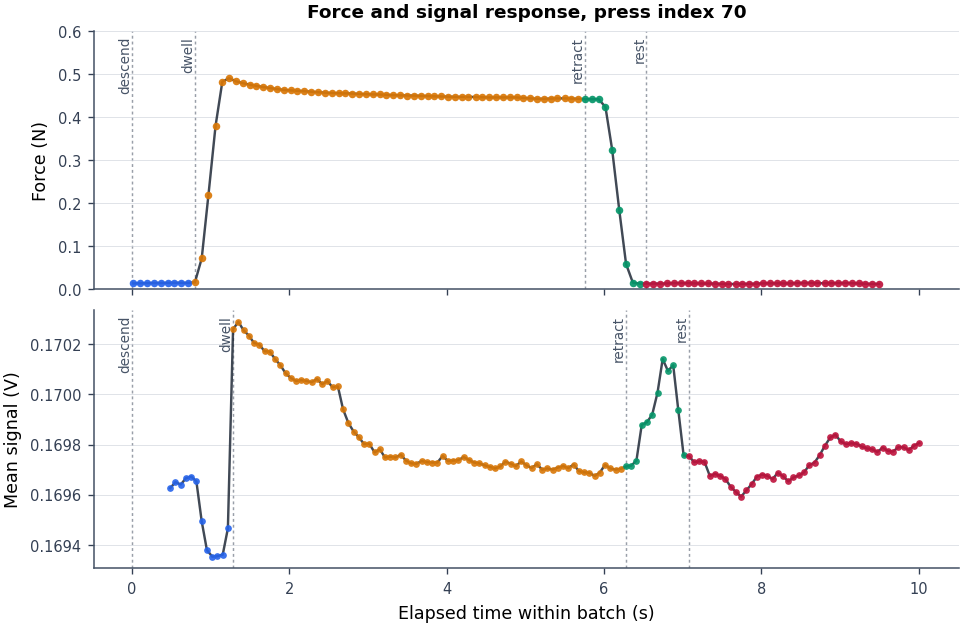

In [110]:
if "bunch_index" not in force_data.columns or "bunch_index" not in eit_data.columns:
    raise KeyError("Expected bunch_index in both force and EIT datasets.")
if time_axis not in force_data.columns or time_axis not in eit_data.columns:
    raise KeyError(f"Expected {time_axis!r} in both force and EIT datasets.")

force_plot = force_data.loc[force_data["bunch_index"].eq(selected_bunch_index)].copy()
eit_plot = eit_data.loc[eit_data["bunch_index"].eq(selected_bunch_index)].copy()

if force_plot.empty:
    raise ValueError(f"No force rows found for bunch_index={selected_bunch_index}.")
if eit_plot.empty:
    raise ValueError(f"No EIT rows found for bunch_index={selected_bunch_index}.")

if "eit_mean" not in eit_plot.columns:
    eit_plot["eit_mean"] = eit_plot[eit_cols].mean(axis=1)

def phase_boundaries_for(frame):
    if "phase" not in frame.columns or time_axis not in frame.columns:
        return pd.DataFrame(columns=[time_axis, "phase"])
    phase_rows = (
        frame[[time_axis, "phase"]]
        .dropna(subset=[time_axis, "phase"])
        .sort_values(time_axis)
        .copy()
    )
    phase_rows["phase"] = phase_rows["phase"].astype(str)
    if phase_rows.empty:
        return pd.DataFrame(columns=[time_axis, "phase"])
    phase_rows["phase_changed"] = phase_rows["phase"].ne(phase_rows["phase"].shift())
    return phase_rows.loc[phase_rows["phase_changed"]].iloc[1:].copy()

force_phase_boundaries = phase_boundaries_for(force_plot)

fig, axes = plt.subplots(2, 1, figsize=(6.9, 4.5), sharex=True, constrained_layout=True)

axes[0].plot(
    force_plot[time_axis],
    force_plot["force_N"],
    color=MAIN_LINE,
    linewidth=1.25,
    alpha=0.85,
    zorder=2,
)
axes[1].plot(
    eit_plot[time_axis],
    eit_plot["eit_mean"],
    color=MAIN_LINE,
    linewidth=1.25,
    alpha=0.85,
    zorder=2,
)

if "phase" in force_plot.columns:
    for phase, phase_data in force_plot.dropna(subset=["phase"]).groupby(force_plot["phase"].astype(str), sort=False):
        axes[0].scatter(
            phase_data[time_axis],
            phase_data["force_N"],
            color=phase_color(phase),
            s=15,
            label=phase,
            alpha=0.92,
            linewidths=0,
            zorder=3,
        )
else:
    axes[0].scatter(force_plot[time_axis], force_plot["force_N"], color=PHASE_PALETTE["descend"], s=15, alpha=0.9, linewidths=0)

if "phase" in eit_plot.columns:
    for phase, phase_data in eit_plot.dropna(subset=["phase"]).groupby(eit_plot["phase"].astype(str), sort=False):
        axes[1].scatter(
            phase_data[time_axis],
            phase_data["eit_mean"],
            color=phase_color(phase),
            s=12,
            label=phase,
            alpha=0.9,
            linewidths=0,
            zorder=3,
        )
else:
    axes[1].scatter(eit_plot[time_axis], eit_plot["eit_mean"], color=PHASE_PALETTE["dwell"], s=12, alpha=0.9, linewidths=0)

def draw_phase_boundaries(ax, boundaries):
    line_style = {"color": "#344054", "linestyle": (0, (2, 2)), "linewidth": 0.75, "alpha": 0.5, "zorder": 1}
    ax.axvline(0, **line_style)
    ax.text(
        0,
        0.98,
        "descend",
        rotation=90,
        va="top",
        ha="right",
        fontsize=7,
        color="#475467",
        transform=ax.get_xaxis_transform(),
    )
    for _, boundary in boundaries.iterrows():
        boundary_time = boundary[time_axis]
        phase_label = boundary["phase"]
        ax.axvline(boundary_time, **line_style)
        ax.text(
            boundary_time,
            0.98,
            phase_label,
            rotation=90,
            va="top",
            ha="right",
            fontsize=7,
            color="#475467",
            transform=ax.get_xaxis_transform(),
        )


draw_phase_boundaries(axes[0], force_phase_boundaries)
draw_phase_boundaries(axes[1], force_phase_boundaries)
axes[0].set_ylim(0,0.6)
x_label = "Elapsed time within batch (s)" if time_axis == "bunch_elapsed_s" else "Timestamp (s)"
polish_axis(axes[0], ylabel="Force (N)", title=f"Force and signal response, press index {selected_bunch_index}")
polish_axis(axes[1], xlabel=x_label, ylabel="Mean signal (V)")
# tidy_legend(axes[0], title="Phase", loc="upper right", ncol=3)
# tidy_legend(axes[1], title="Phase", loc="upper right", ncol=3)

save_paper_figure(fig, f"ForceEIT_Batch{selected_bunch_index}")
plt.show()


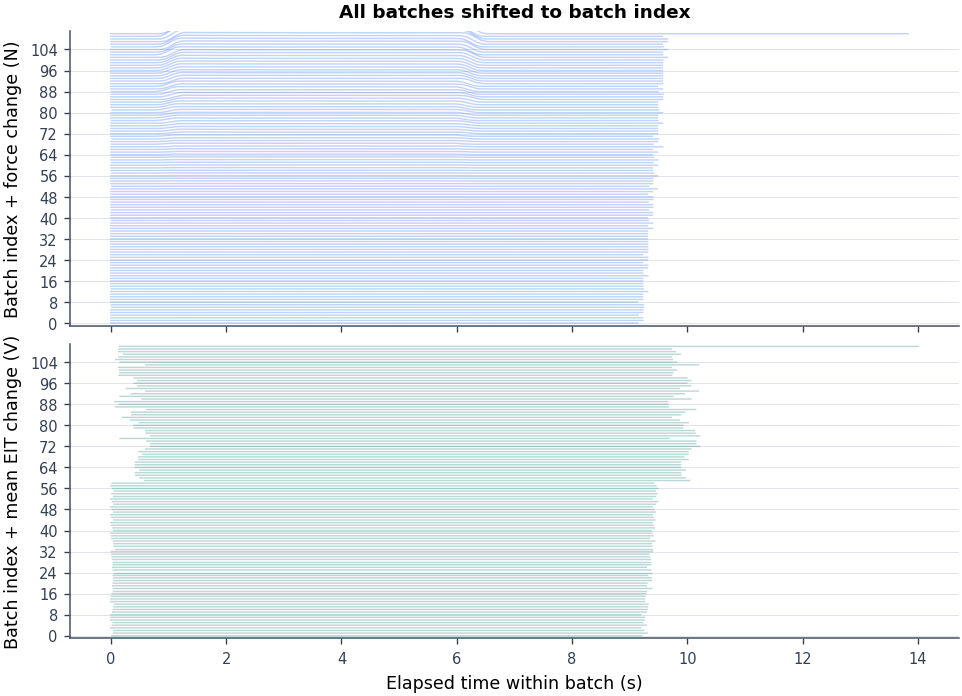

In [111]:
if "bunch_index" not in force_data.columns or "bunch_index" not in eit_data.columns:
    raise KeyError("Expected bunch_index in both force and EIT datasets.")
if "bunch_elapsed_s" not in force_data.columns or "bunch_elapsed_s" not in eit_data.columns:
    raise KeyError("Expected bunch_elapsed_s in both force and EIT datasets.")
if "eit_mean" not in eit_data.columns:
    eit_data["eit_mean"] = eit_data[eit_cols].mean(axis=1)

force_batches = force_data.dropna(subset=["bunch_index", "bunch_elapsed_s", "force_N"]).copy()
eit_batches = eit_data.dropna(subset=["bunch_index", "bunch_elapsed_s", "eit_mean"]).copy()
force_batches = force_batches.loc[force_batches["bunch_index"].ge(0)]
eit_batches = eit_batches.loc[eit_batches["bunch_index"].ge(0)]

if force_batches.empty:
    raise ValueError("No force rows found for batch time plot.")
if eit_batches.empty:
    raise ValueError("No EIT rows found for batch time plot.")

def signal_on_batch_axis(batch, value_col):
    values = batch[value_col].astype(float)
    shifted_signal = values - values.iloc[0]
    return batch["bunch_index"].astype(float) + shifted_signal

fig, axes = plt.subplots(2, 1, figsize=(6.9, 5.0), sharex=True, sharey=True, constrained_layout=True)

for bunch_index, batch in force_batches.groupby("bunch_index", sort=True):
    batch = batch.sort_values("bunch_elapsed_s")
    axes[0].plot(
        batch["bunch_elapsed_s"],
        signal_on_batch_axis(batch, "force_N"),
        color="#2563eb",
        linewidth=0.75,
        alpha=0.28,
    )

for bunch_index, batch in eit_batches.groupby("bunch_index", sort=True):
    batch = batch.sort_values("bunch_elapsed_s")
    axes[1].plot(
        batch["bunch_elapsed_s"],
        signal_on_batch_axis(batch, "eit_mean"),
        color="#0f766e",
        linewidth=0.75,
        alpha=0.28,
    )

all_bunches = sorted(
    set(force_batches["bunch_index"].dropna().astype(int))
    | set(eit_batches["bunch_index"].dropna().astype(int))
)
tick_step = max(1, int(np.ceil(len(all_bunches) / 14)))
y_ticks = all_bunches[::tick_step]
for ax in axes:
    ax.set_yticks(y_ticks)
    ax.set_ylim(min(all_bunches) - 1, max(all_bunches) + 1)
    polish_axis(ax)

polish_axis(axes[0], ylabel="Batch index + force change (N)", title="All batches shifted to batch index")
polish_axis(axes[1], xlabel="Elapsed time within batch (s)", ylabel="Batch index + mean EIT change (V)")

save_paper_figure(fig, "AllBatches_ForceEIT_Shifted")
plt.show()


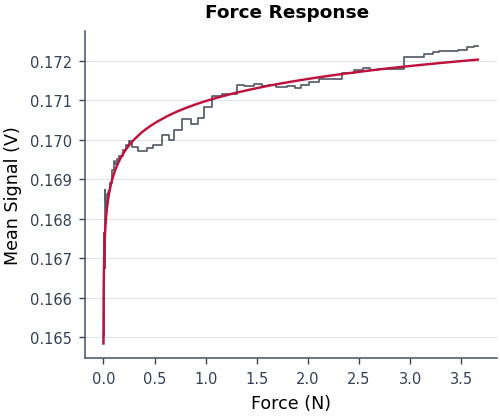

,bunch_index,force_N,eit_mean
0,0,0.000506,0.165029
1,1,0.002009,0.165621
2,2,0.003991,0.165971
3,3,0.004921,0.166561
11,11,0.007876,0.166265


In [112]:
if "bunch_index" not in force_data.columns or "bunch_index" not in eit_data.columns:
    raise KeyError("Expected bunch_index in both force and EIT datasets.")
if "eit_mean" not in eit_data.columns:
    eit_data["eit_mean"] = eit_data[eit_cols].mean(axis=1)

batch_summary_mode = "stable_mean"  # Use "stable_mean" for the flat dwell plateau, or "max" for peak values.
stable_phase = "dwell"
stable_middle_fraction = 0.6

def flat_part_mean(batch, value_col, time_col="timestamp_s"):
    batch = batch.dropna(subset=[value_col, time_col]).sort_values(time_col).copy()
    if batch.empty:
        return np.nan
    if len(batch) < 3:
        return batch[value_col].mean()
    start_quantile = (1 - stable_middle_fraction) / 2
    end_quantile = 1 - start_quantile
    start_time = batch[time_col].quantile(start_quantile)
    end_time = batch[time_col].quantile(end_quantile)
    stable_rows = batch.loc[batch[time_col].between(start_time, end_time)]
    if stable_rows.empty:
        stable_rows = batch
    return stable_rows[value_col].mean()

def summarize_batch(batch, value_col):
    batch = batch.dropna(subset=[value_col]).copy()
    if batch.empty:
        return np.nan
    if batch_summary_mode == "max":
        return batch[value_col].max()
    if batch_summary_mode != "stable_mean":
        raise ValueError("batch_summary_mode must be 'stable_mean' or 'max'.")
    if "phase" in batch.columns:
        stable_rows = batch.loc[batch["phase"].astype(str).eq(stable_phase)]
        if not stable_rows.empty:
            return flat_part_mean(stable_rows, value_col)
    return flat_part_mean(batch, value_col)

summary_rows = []
common_bunches = sorted(
    set(force_data["bunch_index"].dropna().astype(int))
    & set(eit_data["bunch_index"].dropna().astype(int))
)
for bunch_index in common_bunches:
    if bunch_index < 0:
        continue
    force_batch = force_data.loc[force_data["bunch_index"].eq(bunch_index)]
    eit_batch = eit_data.loc[eit_data["bunch_index"].eq(bunch_index)]
    force_value = summarize_batch(force_batch, "force_N")
    eit_value = summarize_batch(eit_batch, "eit_mean")
    if np.isfinite(force_value) and np.isfinite(eit_value):
        summary_rows.append({"bunch_index": bunch_index, "force_N": force_value, "eit_mean": eit_value})

batch_summary = pd.DataFrame(summary_rows).sort_values("force_N")
if batch_summary.empty:
    raise ValueError("No batch summary values could be computed.")

fig, ax = plt.subplots(figsize=(3.6, 3.0), constrained_layout=True)
# scatter = ax.scatter(
#     batch_summary["force_N"],
#     batch_summary["eit_mean"],
#     c=batch_summary["bunch_index"],
#     cmap="viridis",
#     s=24,
#     alpha=0.88,
#     edgecolors="white",
#     linewidths=0.35,
#     label="Batch summary",
#     zorder=3,
# )
ax.step(
    batch_summary["force_N"],
    batch_summary["eit_mean"],
    where="mid",
    color=MAIN_LINE,
    linewidth=0.9,
    alpha=0.75,
    label="Force-sorted trace",
    zorder=2,
)
polish_axis(
    ax,
    xlabel="Force (N)",
    ylabel="Mean Signal (V)",
    title=f"Force Response ",
)
# tidy_legend(ax, loc="best")
# cbar = fig.colorbar(scatter, ax=ax, pad=0.025, fraction=0.06)
# cbar.set_label("Press index")
# cbar.outline.set_linewidth(0.6)

#Plot line of best fit (assuming plot looks like ln(x))

best_fit_coeffs = np.polyfit(np.log(batch_summary["force_N"]), batch_summary["eit_mean"], deg=1)
best_fit_line = np.poly1d(best_fit_coeffs)
ax.plot(
    batch_summary["force_N"],
    best_fit_line(np.log(batch_summary["force_N"])),
    color="#be123c",
)


save_paper_figure(fig, f"BatchSummary_{batch_summary_mode}")
plt.show()

display(batch_summary.head())


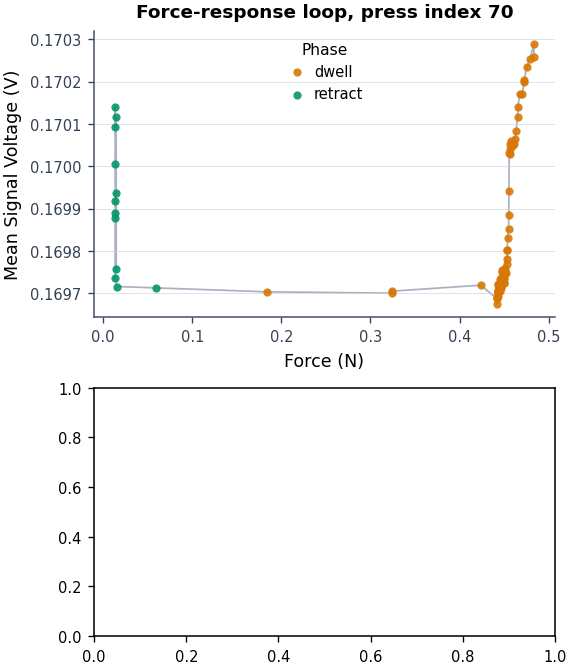

,timestamp_s,eit_mean,bunch_elapsed_s,phase,force_timestamp_s,force_N,force_match_dt_s
12,717.0850,0.170259,1.2864,dwell,717.1207,0.4834,-0.0357
13,717.1521,0.170289,1.3535,dwell,717.1207,0.4834,0.0314
14,717.2199,0.170255,1.4213,dwell,717.2107,0.4790,0.0092
15,717.2857,0.170234,1.4871,dwell,717.2968,0.4754,-0.0111
16,717.3512,0.170205,1.5526,dwell,717.3829,0.4726,-0.0317


In [113]:
if "bunch_index" not in force_data.columns or "bunch_index" not in eit_data.columns:
    raise KeyError("Expected bunch_index in both force and EIT datasets.")

excluded_hysteresis_phases = {"descend", "rest"}

force_plot = (
    force_data.loc[force_data["bunch_index"].eq(selected_bunch_index), ["timestamp_s", "force_N"]]
    .dropna(subset=["timestamp_s", "force_N"])
    .sort_values("timestamp_s")
)
eit_plot = (
    eit_data.loc[eit_data["bunch_index"].eq(selected_bunch_index)].copy()
    .dropna(subset=["timestamp_s"])
    .sort_values("timestamp_s")
)

if force_plot.empty:
    raise ValueError(f"No force rows found for bunch_index={selected_bunch_index}.")
if eit_plot.empty:
    raise ValueError(f"No EIT rows found for bunch_index={selected_bunch_index}.")

if "eit_mean" not in eit_plot.columns:
    eit_plot["eit_mean"] = eit_plot[eit_cols].mean(axis=1)

merge_cols = ["timestamp_s", "eit_mean"]
if "bunch_elapsed_s" in eit_plot.columns:
    merge_cols.append("bunch_elapsed_s")
if "phase" in eit_plot.columns:
    merge_cols.append("phase")

force_vs_eit = pd.merge_asof(
    eit_plot[merge_cols].dropna(subset=["eit_mean"]),
    force_plot.rename(columns={"timestamp_s": "force_timestamp_s"}),
    left_on="timestamp_s",
    right_on="force_timestamp_s",
    direction="nearest",
)
force_vs_eit["force_match_dt_s"] = force_vs_eit["timestamp_s"] - force_vs_eit["force_timestamp_s"]
if "phase" not in force_vs_eit.columns:
    force_vs_eit["phase"] = "unknown"
force_vs_eit["phase"] = force_vs_eit["phase"].astype(str)
force_vs_eit["phase_lower"] = force_vs_eit["phase"].str.lower()

hysteresis_data = force_vs_eit.loc[
    ~force_vs_eit["phase_lower"].isin(excluded_hysteresis_phases)
].dropna(subset=["force_N", "eit_mean"]).copy()
if hysteresis_data.empty:
    raise ValueError("No rows remain after filtering descend/rest from the hysteresis plot.")

time_col = "bunch_elapsed_s" if "bunch_elapsed_s" in hysteresis_data.columns else "timestamp_s"
time_label = "Elapsed time within batch (s)" if time_col == "bunch_elapsed_s" else "Timestamp (s)"

fig, axes = plt.subplots(
    2,
    1,
    figsize=(4.1, 4.8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1.15, 1.0]},
)

axes[0].plot(
    hysteresis_data["force_N"],
    hysteresis_data["eit_mean"],
    color=SECONDARY_LINE,
    linewidth=0.9,
    alpha=0.55,
    zorder=1,
)
# axes[1].plot(
#     hysteresis_data[time_col],
#     hysteresis_data["eit_mean"],
#     color=SECONDARY_LINE,
#     linewidth=0.9,
#     alpha=0.55,
#     zorder=1,
# )

for phase, phase_data in hysteresis_data.groupby("phase", sort=False):
    marker_color = phase_color(phase)
    axes[0].scatter(
        phase_data["force_N"],
        phase_data["eit_mean"],
        color=marker_color,
        s=18,
        alpha=0.9,
        label=phase,
        linewidths=0,
        zorder=2,
    )
    # axes[1].scatter(
    #     phase_data[time_col],
    #     phase_data["eit_mean"],
    #     color=marker_color,
    #     s=16,
    #     alpha=0.9,
    #     label=phase,
    #     linewidths=0,
    #     zorder=2,
    # )

# arrow_source = hysteresis_data.reset_index(drop=True)
# if len(arrow_source) > 1:
#     arrow_count = min(8, max(3, len(arrow_source) // 12))
#     arrow_indices = np.linspace(0, len(arrow_source) - 2, arrow_count, dtype=int)
#     for idx in np.unique(arrow_indices):
#         start = arrow_source.iloc[idx]
#         end = arrow_source.iloc[idx + 1]
#         axes[0].annotate(
#             "",
#             xy=(end["force_N"], end["eit_mean"]),
#             xytext=(start["force_N"], start["eit_mean"]),
#             arrowprops={"arrowstyle": "->", "color": MAIN_LINE, "lw": 0.8, "alpha": 0.55, "shrinkA": 1.5, "shrinkB": 1.5},
#             zorder=3,
#         )

polish_axis(
    axes[0],
    xlabel="Force (N)",
    ylabel="Mean Signal Voltage (V)",
    title=f"Force-response loop, press index {selected_bunch_index}",
)
# polish_axis(
#     axes[1],
#     xlabel=time_label,
#     ylabel="Mean Signal Voltage (V)",
#     title="Signal drift within retained phases",
# )
tidy_legend(axes[0], title="Phase", loc="best")
# tidy_legend(axes[1], title="Phase", loc="best")

filter_tag = "no_" + "_".join(sorted(excluded_hysteresis_phases))
save_paper_figure(fig, f"FilteredHysteresis_Batch{selected_bunch_index}_{filter_tag}")
plt.show()

display(hysteresis_data.drop(columns=["phase_lower"]).head())
